# Low-resource CRNN synthetic-augmentation experiment

**Question.** If a newly initialized CRNN can see only 50 labeled real spectrograms per species, do refreshed VAE-v3 or diffusion spectrograms improve classification of real held-out clips?

This is a **report-only** notebook. It reads the finalized bounded package under `reports/crnn_low_resource_augmentation_2026-08-12/` and never reads checkpoints, trains a model, or generates a spectrogram. Its cached outputs are produced only from that protocol-4 package.

The experiment simulates classifier-label scarcity for the repository's three existing species. It is not evidence about genuinely rare or unseen species.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'reports').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the bird_song_gen project root')


PROJECT_ROOT = find_project_root(Path.cwd())
REPORT_DIR = PROJECT_ROOT / 'reports' / 'crnn_low_resource_augmentation_2026-08-12'
MODEL_ORDER = ['vae_v3', 'diffusion']
MODEL_LABELS = {'vae_v3': 'VAE-v3', 'diffusion': 'Diffusion'}
MODEL_COLORS = {'vae_v3': '#2E86AB', 'diffusion': '#E07A5F'}
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
print(f'Expected fresh report: {REPORT_DIR.relative_to(PROJECT_ROOT)}')

Expected fresh report: reports\crnn_low_resource_augmentation_2026-08-12


## 1. Load the fresh report package

The file gate below prevents accidental fallback to an older report or a partially packaged run.

In [2]:
required_report_files = [
    'protocol.json', 'summary.json', 'provenance.json', 'input_audit.json',
    'validation_per_run.csv', 'validation_selection.csv',
    'test_aggregate.csv', 'test_per_run.csv',
    'paired_deltas.csv', 'paired_summary.csv',
    'subset_membership.csv', 'subset_overlap.csv',
]
missing_report_files = [
    name for name in required_report_files if not (REPORT_DIR / name).is_file()
]
if missing_report_files:
    raise FileNotFoundError(
        'Fresh low-resource report is not complete. Package the 2026-08-12 run before '
        f'executing this notebook; missing: {missing_report_files}'
    )

protocol = json.loads((REPORT_DIR / 'protocol.json').read_text(encoding='utf-8'))
summary = json.loads((REPORT_DIR / 'summary.json').read_text(encoding='utf-8'))
provenance = json.loads((REPORT_DIR / 'provenance.json').read_text(encoding='utf-8'))
input_audit = json.loads((REPORT_DIR / 'input_audit.json').read_text(encoding='utf-8'))
validation_per_run = pd.read_csv(REPORT_DIR / 'validation_per_run.csv')
validation_selection = pd.read_csv(REPORT_DIR / 'validation_selection.csv')
test_aggregate = pd.read_csv(REPORT_DIR / 'test_aggregate.csv')
test_per_run = pd.read_csv(REPORT_DIR / 'test_per_run.csv')
paired_deltas = pd.read_csv(REPORT_DIR / 'paired_deltas.csv')
paired_summary = pd.read_csv(REPORT_DIR / 'paired_summary.csv')
subset_membership = pd.read_csv(REPORT_DIR / 'subset_membership.csv')
subset_overlap = pd.read_csv(REPORT_DIR / 'subset_overlap.csv')
print(f'Report package loaded: {REPORT_DIR.relative_to(PROJECT_ROOT)}')

Report package loaded: reports\crnn_low_resource_augmentation_2026-08-12


## 2. Current protocol and exact nine-block audit

This audit fixes the intended experiment identity before any score is interpreted: protocol version 4, one CRNN architecture, the complete 50+0/50/100/200 matrix, the exact nine subset/training/pool-seed triples, generator-safe validation, and the recorded pool-refresh boundary.

In [3]:
assert protocol['schema_version'] == 2
assert summary['schema_version'] == 2
assert provenance['schema_version'] == 2
assert input_audit['schema_version'] == 2
assert input_audit['pool_audit']['schema_version'] == 2
assert {
    protocol['protocol_version'], summary['protocol_version'],
    provenance['protocol_version'], input_audit['protocol_version'],
} == {4}
assert protocol['training_protocol']['protocol_version'] == 4
assert protocol['training_protocol']['architecture'] == 'crnn'
assert protocol['checkpoint_count'] == 63
assert protocol['real_per_species'] == 50
assert protocol['ratios_per_species'] == [50, 100, 200]
assert protocol['real_subset_seeds'] == [101, 202, 303]
assert protocol['train_seeds'] == [42, 123, 777]
assert protocol['pool_seeds'] == [42, 123, 777]

validation_identity = protocol['validation_protocol_identity']
assert validation_identity == input_audit['validation_protocol_identity']
assert protocol['validation_manifest'] == (
    'manifests/content_safe_v2/full_dataset_validation_generator_safe.csv'
)
assert protocol['test_manifest'] == 'manifests/content_safe_v2/full_dataset_test.csv'
assert validation_identity['validation_counts']['before'] == {
    'rows': 519,
    'species': {
        'American Robin': 163, 'Northern Cardinal': 172, 'Song Sparrow': 184,
    },
}
assert validation_identity['validation_counts']['after'] == {
    'rows': 510,
    'species': {
        'American Robin': 163, 'Northern Cardinal': 172, 'Song Sparrow': 175,
    },
}
assert len(validation_identity['excluded_validation_relative_wav_paths']) == 9
assert validation_identity['test_unchanged']['rows'] == 489
assert validation_identity['test_unchanged']['excluded_rows'] == 0
expected_evidence_boundaries = {
    'generator_safe_validation_rows': 510, 'held_out_test_rows': 489,
}
assert protocol['evidence_boundaries'] == expected_evidence_boundaries
assert summary['evidence_boundaries'] == expected_evidence_boundaries
assert {
    key: provenance['evidence_boundaries'][key]
    for key in expected_evidence_boundaries
} == expected_evidence_boundaries
assert provenance['evidence_boundaries']['checkpoint_count'] == 63
assert provenance['evidence_boundaries']['validation_protocol_identity'] == validation_identity

pool_provenance = protocol['pool_provenance']
assert pool_provenance == summary['pool_provenance'] == provenance['pool_provenance']
assert pool_provenance['source_schema_version'] == 3
assert pool_provenance['low_resource_pool_generation_performed'] is False
vae_pool = pool_provenance['models']['vae_v3']
diffusion_pool = pool_provenance['models']['diffusion']
for pool_record in (vae_pool, diffusion_pool):
    assert pool_record['pool_seeds'] == [42, 123, 777]
    assert pool_record['samples_per_pool'] == 600
vae_contract = vae_pool['generation_contract']
assert vae_contract['temperature'] == 0.35
assert vae_contract['reparameterization'] == (
    'mu + temperature * exp(0.5 * logvar) * epsilon'
)
assert vae_contract['posterior_bank_contract'] == (
    'content_safe_v2_train_filtered_existing_bank_v1'
)
assert vae_contract['posterior_bank_counts'] == {
    'Northern Cardinal': 256, 'Song Sparrow': 247, 'American Robin': 256,
}
assert vae_contract['posterior_bank_derivation'] == 'filtered_existing_posterior_bank'
assert vae_contract['vae_checkpoint_retrained'] is False
assert vae_pool['checkpoint_not_retrained'] is True
assert vae_pool['pool_reused_after_vae_bank_filter'] is False
assert vae_pool['spectrograms_regenerated_after_vae_bank_filter'] is True
diffusion_contract = diffusion_pool['generation_contract']
assert diffusion_contract['sampler'] == 'ddim'
assert diffusion_contract['ddim_steps'] == 100
assert diffusion_contract['ddim_eta'] == 0.0
assert diffusion_contract['guidance_weight'] == 3.0
assert diffusion_contract['clamp_samples'] == 4.0
assert diffusion_contract['checkpoint_epoch'] == 34
assert diffusion_contract['checkpoint_selection'] == 'validation_best'
assert diffusion_contract['stored_sampler_overridden'] == 'ddpm'
assert diffusion_pool['pool_reused_after_vae_bank_filter'] is True
assert diffusion_pool['spectrograms_regenerated_after_vae_bank_filter'] is False

assert len(input_audit['pool_details']) == 6
for pool_detail in input_audit['pool_details']:
    generation = pool_detail['generation_identity']['generation']
    assert generation['schema_version'] == 3
    assert generation['generator'] == pool_detail['model']
    assert generation['seed'] == pool_detail['seed']
    assert generation['samples_per_class'] == 200
    assert pool_detail['rows'] == 600
    if pool_detail['model'] == 'vae_v3':
        assert generation['temperature'] == vae_contract['temperature']
        assert generation['reparameterization'] == vae_contract['reparameterization']
        assert generation['posterior_bank_contract'] == vae_contract['posterior_bank_contract']
        assert generation['posterior_bank_counts'] == vae_contract['posterior_bank_counts']
        assert generation['vae_checkpoint_retrained'] is False
    else:
        for key in (
            'sampler', 'ddim_steps', 'ddim_eta', 'guidance_weight',
            'clamp_samples', 'checkpoint_epoch', 'checkpoint_selection',
            'stored_sampler_overridden',
        ):
            assert generation[key] == diffusion_contract[key]

expected_blocks = [
    {'real_subset_seed': 101, 'train_seed': 42, 'pool_seed': 42},
    {'real_subset_seed': 101, 'train_seed': 123, 'pool_seed': 123},
    {'real_subset_seed': 101, 'train_seed': 777, 'pool_seed': 777},
    {'real_subset_seed': 202, 'train_seed': 42, 'pool_seed': 123},
    {'real_subset_seed': 202, 'train_seed': 123, 'pool_seed': 777},
    {'real_subset_seed': 202, 'train_seed': 777, 'pool_seed': 42},
    {'real_subset_seed': 303, 'train_seed': 42, 'pool_seed': 777},
    {'real_subset_seed': 303, 'train_seed': 123, 'pool_seed': 42},
    {'real_subset_seed': 303, 'train_seed': 777, 'pool_seed': 123},
]
assert protocol['replicate_blocks'] == expected_blocks
assert input_audit['replicate_blocks'] == expected_blocks

expected_conditions = [
    {'condition': 'real_only', 'generator': None, 'ratio_per_species': 0},
    *[
        {
            'condition': f'{model}_plus_{ratio}',
            'generator': model,
            'ratio_per_species': ratio,
        }
        for model in MODEL_ORDER
        for ratio in protocol['ratios_per_species']
    ],
]
assert input_audit['conditions'] == expected_conditions
assert input_audit['expected_training_runs'] == len(expected_blocks) * len(expected_conditions) == 63

expected_validation_pairs = {
    (model, ratio)
    for model in MODEL_ORDER
    for ratio in protocol['ratios_per_species']
}
assert set(zip(
    validation_selection['generator'], validation_selection['ratio_per_species']
)) == expected_validation_pairs
assert validation_selection['runs'].eq(len(expected_blocks)).all()
assert len(validation_per_run) == len(expected_blocks) * len(expected_conditions)
assert validation_per_run['condition'].value_counts().to_dict() == {
    condition['condition']: len(expected_blocks) for condition in expected_conditions
}

selected_mask = validation_selection['selected_for_test'].astype(str).str.lower().eq('true')
selected_rows = validation_selection[selected_mask]
selected_ratios = {
    row.generator: int(row.ratio_per_species)
    for row in selected_rows.itertuples(index=False)
}
assert set(selected_ratios) == set(MODEL_ORDER)
assert selected_ratios == {key: int(value) for key, value in protocol['selected_ratios'].items()}
assert selected_ratios == {key: int(value) for key, value in summary['selected_ratios'].items()}

condition_codes = {
    'real_only': 'real_only',
    **{model: f'{model}_plus_{selected_ratios[model]}' for model in MODEL_ORDER},
}
condition_labels = {
    'real_only': 'Real only',
    **{
        condition_codes[model]: f'{MODEL_LABELS[model]} +{selected_ratios[model]}'
        for model in MODEL_ORDER
    },
}
condition_colors = {
    'Real only': '#5B6770',
    **{condition_labels[condition_codes[model]]: MODEL_COLORS[model] for model in MODEL_ORDER},
}
assert set(test_aggregate['condition']) == set(condition_labels)
assert test_aggregate['runs'].eq(len(expected_blocks)).all()
assert len(test_per_run) == len(expected_blocks) * len(condition_labels) == 27
assert test_per_run['condition'].value_counts().to_dict() == {
    condition: len(expected_blocks) for condition in condition_labels
}
assert test_per_run['sample_count'].eq(489).all()
assert len(paired_deltas) == len(expected_blocks) * len(MODEL_ORDER) == 18
assert set(paired_summary['generator']) == set(MODEL_ORDER)
assert paired_summary['paired_blocks'].eq(len(expected_blocks)).all()
assert {
    row.generator: int(row.selected_ratio_per_species)
    for row in paired_summary.itertuples(index=False)
} == selected_ratios

membership_counts = subset_membership.groupby(['low_resource_subset_seed', 'name']).size()
recording_counts = subset_membership.groupby(
    ['low_resource_subset_seed', 'name']
)["id"].nunique()
assert membership_counts.eq(protocol['real_per_species']).all()
assert recording_counts.eq(protocol['real_per_species']).all()
assert len(subset_membership) == len(protocol['real_subset_seeds']) * 3 * protocol['real_per_species']
assert len(subset_overlap) == 9

audit = pd.DataFrame({
    'Check': [
        'Protocol version', 'CRNN-only architecture', 'Matched blocks',
        'Conditions per block', 'Total training runs', 'Held-out evaluations',
        'Generator-safe validation clips', 'Test clips per evaluation',
        'Distinct recording IDs per subset/species', 'VAE checkpoint retrained',
        'Diffusion pools regenerated',
    ],
    'Observed': [4, 'crnn', 9, 7, 63, 27, 510, 489, 50, False, False],
    'Status': ['pass'] * 11,
})
display(audit)

,Check,Observed,Status
0,Protocol version,4,pass
1,CRNN-only architecture,crnn,pass
2,Matched blocks,9,pass
3,Conditions per block,7,pass
4,Total training runs,63,pass
5,Held-out evaluations,27,pass
6,Generator-safe validation clips,510,pass
7,Test clips per evaluation,489,pass
8,Distinct recording IDs per subset/species,50,pass
9,VAE checkpoint retrained,False,pass


## 3. Experimental design

Each real subset contains 50 rows per species from distinct recording IDs. Every matched block trains seven from-scratch CRNN conditions: the 50+0 real-only control plus VAE-v3 and diffusion arms at 50+50, 50+100, and 50+200 per species. All conditions use the same optimizer-step budget, the 510-row generator-safe real-validation split, and post-cache masking policy. The test split remains unchanged at 489 real clips. Generation-pool seeds rotate through the nine blocks by the fixed Latin square above.

In [4]:
block_view = pd.DataFrame(expected_blocks).rename(columns={
    'real_subset_seed': 'Real-subset seed',
    'train_seed': 'CRNN seed',
    'pool_seed': 'Pool seed',
})
display(block_view)

condition_matrix = pd.DataFrame(expected_conditions)
condition_matrix['Real/species'] = protocol['real_per_species']
condition_matrix['Generated/species'] = condition_matrix['ratio_per_species']
condition_matrix['Total/species'] = (
    condition_matrix['Real/species'] + condition_matrix['Generated/species']
)
condition_matrix['Synthetic share'] = (
    condition_matrix['Generated/species'] / condition_matrix['Total/species']
)
condition_matrix['Condition'] = condition_matrix.apply(
    lambda row: (
        f"{int(row['Real/species'])}+0 real-only"
        if pd.isna(row['generator'])
        else (
            f"{int(row['Real/species'])}+{int(row['Generated/species'])} "
            f"{MODEL_LABELS[row['generator']]}"
        )
    ),
    axis=1,
)
display(condition_matrix[[
    'Condition', 'Real/species', 'Generated/species', 'Total/species', 'Synthetic share',
]].style.format({'Synthetic share': '{:.1%}'}))

training_protocol_view = pd.DataFrame([
    {'Item': key, 'Value': value}
    for key, value in protocol['training_protocol'].items()
])
display(training_protocol_view)

,Real-subset seed,CRNN seed,Pool seed
0,101,42,42
1,101,123,123
2,101,777,777
3,202,42,123
4,202,123,777
5,202,777,42
6,303,42,777
7,303,123,42
8,303,777,123


,Condition,Real/species,Generated/species,Total/species,Synthetic share
0,50+0 real-only,50,0,50,0.0%
1,50+50 VAE-v3,50,50,100,50.0%
2,50+100 VAE-v3,50,100,150,66.7%
3,50+200 VAE-v3,50,200,250,80.0%
4,50+50 Diffusion,50,50,100,50.0%
5,50+100 Diffusion,50,100,150,66.7%
6,50+200 Diffusion,50,200,250,80.0%


,Item,Value
0,protocol_version,4
1,architecture,crnn
2,model_width,32
3,model_dropout,0.3
4,initialization,from scratch for every replicate block and con...
5,optimizer,AdamW
6,learning_rate,0.0003
7,weight_decay,0.0001
8,scheduler,CosineAnnealingLR over fixed optimizer steps
9,label_smoothing,0.05


### Real-subset dependence

Recording IDs are distinct within each subset/species, but the three subsets cannot be treated as independent datasets. The overlap table below makes that dependence visible.

In [5]:
overlap_view = subset_overlap.rename(columns={
    'species': 'Species',
    'subset_seed_a': 'Subset A',
    'subset_seed_b': 'Subset B',
    'shared_recording_ids': 'Shared recording IDs',
    'union_recording_ids': 'Union recording IDs',
    'jaccard_overlap': 'Jaccard overlap',
})
display(overlap_view.style.format({'Jaccard overlap': '{:.1%}'}))

,Species,Subset A,Subset B,Shared recording IDs,Union recording IDs,Jaccard overlap
0,American Robin,101,202,45,55,81.8%
1,American Robin,101,303,44,56,78.6%
2,American Robin,202,303,46,54,85.2%
3,Northern Cardinal,101,202,39,61,63.9%
4,Northern Cardinal,101,303,38,62,61.3%
5,Northern Cardinal,202,303,41,59,69.5%
6,Song Sparrow,101,202,29,71,40.8%
7,Song Sparrow,101,303,27,73,37.0%
8,Song Sparrow,202,303,28,72,38.9%


## 4. Validation-only ratio selection

For each generator, validation chooses the smallest tested ratio within 0.002 of its best mean macro F1 across all nine blocks. The notebook derives both selected ratios from the fresh report; no ratio is preselected in the notebook.

,Generator,Generated/species,Runs,Mean macro F1,Sample SD,Minimum,Maximum,Selected
0,VAE-v3,50,9,84.53%,1.98%,81.39%,87.07%,False
1,VAE-v3,100,9,85.88%,1.82%,82.89%,87.63%,False
2,VAE-v3,200,9,86.47%,1.55%,83.93%,89.42%,True
3,Diffusion,50,9,85.45%,2.22%,83.28%,89.82%,False
4,Diffusion,100,9,86.06%,1.69%,83.48%,88.96%,False
5,Diffusion,200,9,86.84%,1.30%,85.23%,88.47%,True


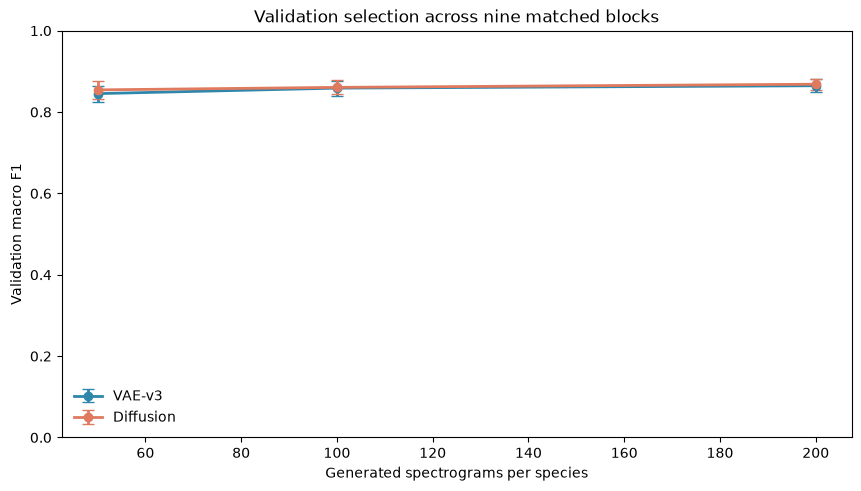

VAE-v3 selected +200 per species from validation.
Diffusion selected +200 per species from validation.


In [6]:
recomputed_validation = (
    validation_per_run[validation_per_run['generator'].isin(MODEL_ORDER)]
    .groupby(['generator', 'ratio_per_species'])['validation_macro_f1']
    .agg(runs='count', mean='mean', sample_sd='std', minimum='min', maximum='max')
    .reset_index()
)
validation_check = validation_selection.merge(
    recomputed_validation, on=['generator', 'ratio_per_species'], validate='one_to_one'
)
assert (validation_check['runs_x'] == validation_check['runs_y']).all()
assert np.allclose(validation_check['validation_macro_f1_mean'], validation_check['mean'])
assert np.allclose(validation_check['validation_macro_f1_sample_sd'], validation_check['sample_sd'])
assert np.allclose(validation_check['validation_macro_f1_min'], validation_check['minimum'])
assert np.allclose(validation_check['validation_macro_f1_max'], validation_check['maximum'])
for model in MODEL_ORDER:
    model_rows = validation_selection[validation_selection['generator'] == model]
    best_mean = float(model_rows['validation_macro_f1_mean'].max())
    eligible = model_rows[
        best_mean - model_rows['validation_macro_f1_mean'] <= 0.002 + 1e-12
    ]
    assert selected_ratios[model] == int(eligible['ratio_per_species'].min())

validation_view = validation_selection[[
    'generator', 'ratio_per_species', 'runs', 'validation_macro_f1_mean',
    'validation_macro_f1_sample_sd', 'validation_macro_f1_min',
    'validation_macro_f1_max', 'selected_for_test',
]].copy()
validation_view['generator'] = validation_view['generator'].map(MODEL_LABELS)
validation_view = validation_view.rename(columns={
    'generator': 'Generator',
    'ratio_per_species': 'Generated/species',
    'runs': 'Runs',
    'validation_macro_f1_mean': 'Mean macro F1',
    'validation_macro_f1_sample_sd': 'Sample SD',
    'validation_macro_f1_min': 'Minimum',
    'validation_macro_f1_max': 'Maximum',
    'selected_for_test': 'Selected',
})
display(validation_view.style.format({
    'Mean macro F1': '{:.2%}', 'Sample SD': '{:.2%}',
    'Minimum': '{:.2%}', 'Maximum': '{:.2%}',
}))

figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    group = validation_view[validation_view['Generator'] == label].sort_values('Generated/species')
    axis.errorbar(
        group['Generated/species'], group['Mean macro F1'],
        yerr=group['Sample SD'], marker='o', capsize=4, linewidth=2,
        color=MODEL_COLORS[model], label=label,
    )
axis.set(
    xlabel='Generated spectrograms per species', ylabel='Validation macro F1',
    ylim=(0, 1), title='Validation selection across nine matched blocks',
)
axis.legend(frameon=False)
plt.show()
for model in MODEL_ORDER:
    print(f'{MODEL_LABELS[model]} selected +{selected_ratios[model]} per species from validation.')

## 5. CRNN-only held-out utility and paired deltas

Only the real-only control and one validation-selected arm per generator reach the fixed real test split. Comparisons are paired within the same real-subset and CRNN-initialization block. The deterministic block bootstrap is a descriptive stability interval, not a p-value or a confidence interval over independent test recordings.

In [7]:
aggregate_recomputed = (
    test_per_run.groupby('condition', as_index=False)
    .agg(
        runs=('macro_f1', 'size'),
        accuracy_mean=('accuracy', 'mean'),
        macro_f1_mean=('macro_f1', 'mean'),
    )
)
aggregate_check = test_aggregate.merge(
    aggregate_recomputed, on='condition', suffixes=('_report', '_recomputed'),
    validate='one_to_one',
)
assert (aggregate_check['runs_report'] == aggregate_check['runs_recomputed']).all()
assert np.allclose(aggregate_check['accuracy_mean_report'], aggregate_check['accuracy_mean_recomputed'])
assert np.allclose(aggregate_check['macro_f1_mean_report'], aggregate_check['macro_f1_mean_recomputed'])

aggregate_view = test_aggregate[[
    'condition', 'runs', 'accuracy_mean', 'accuracy_sample_sd',
    'macro_f1_mean', 'macro_f1_sample_sd', 'macro_f1_min', 'macro_f1_max',
    'recall_american_robin_mean', 'recall_northern_cardinal_mean',
    'recall_song_sparrow_mean', 'minimum_species_recall_mean',
]].copy()
aggregate_view['condition'] = aggregate_view['condition'].map(condition_labels)
aggregate_view = aggregate_view.rename(columns={
    'condition': 'Condition', 'runs': 'Runs',
    'accuracy_mean': 'Mean accuracy', 'accuracy_sample_sd': 'Accuracy SD',
    'macro_f1_mean': 'Mean macro F1', 'macro_f1_sample_sd': 'Macro-F1 SD',
    'macro_f1_min': 'Macro-F1 minimum', 'macro_f1_max': 'Macro-F1 maximum',
    'recall_american_robin_mean': 'American Robin recall',
    'recall_northern_cardinal_mean': 'Northern Cardinal recall',
    'recall_song_sparrow_mean': 'Song Sparrow recall',
    'minimum_species_recall_mean': 'Mean worst-species recall',
})
display(aggregate_view.style.format({
    column: '{:.2%}' for column in aggregate_view.columns if column not in {'Condition', 'Runs'}
}))

paired_view = paired_summary[[
    'generator', 'selected_ratio_per_species', 'paired_blocks',
    'delta_accuracy_mean', 'delta_accuracy_sample_sd',
    'delta_macro_f1_mean', 'delta_macro_f1_sample_sd',
    'delta_macro_f1_min', 'delta_macro_f1_max',
    'delta_macro_f1_bootstrap_95_low', 'delta_macro_f1_bootstrap_95_high',
    'delta_macro_f1_positive_blocks',
    'delta_minimum_species_recall_mean',
]].copy()
paired_view['generator'] = paired_view['generator'].map(MODEL_LABELS)
paired_view = paired_view.rename(columns={
    'generator': 'Generator',
    'selected_ratio_per_species': 'Selected generated/species',
    'paired_blocks': 'Blocks',
    'delta_accuracy_mean': 'Mean accuracy delta',
    'delta_accuracy_sample_sd': 'Accuracy-delta SD',
    'delta_macro_f1_mean': 'Mean macro-F1 delta',
    'delta_macro_f1_sample_sd': 'Macro-F1-delta SD',
    'delta_macro_f1_min': 'Minimum macro-F1 delta',
    'delta_macro_f1_max': 'Maximum macro-F1 delta',
    'delta_macro_f1_bootstrap_95_low': 'Interval low',
    'delta_macro_f1_bootstrap_95_high': 'Interval high',
    'delta_macro_f1_positive_blocks': 'Positive blocks',
    'delta_minimum_species_recall_mean': 'Mean worst-species-recall delta',
})
display(paired_view.style.format({
    column: '{:+.2%}'
    for column in paired_view.columns
    if column not in {'Generator', 'Selected generated/species', 'Blocks', 'Positive blocks'}
}))

,Condition,Runs,Mean accuracy,Accuracy SD,Mean macro F1,Macro-F1 SD,Macro-F1 minimum,Macro-F1 maximum,American Robin recall,Northern Cardinal recall,Song Sparrow recall,Mean worst-species recall
0,Real only,9,84.78%,2.42%,84.75%,2.52%,81.02%,90.00%,90.57%,75.38%,88.52%,75.38%
1,VAE-v3 +200,9,87.48%,1.92%,87.48%,2.07%,83.07%,90.03%,94.79%,80.52%,87.85%,79.62%
2,Diffusion +200,9,86.18%,1.05%,86.21%,1.04%,84.80%,88.10%,88.66%,82.51%,87.48%,82.32%


,Generator,Selected generated/species,Blocks,Mean accuracy delta,Accuracy-delta SD,Mean macro-F1 delta,Macro-F1-delta SD,Minimum macro-F1 delta,Maximum macro-F1 delta,Interval low,Interval high,Positive blocks,Mean worst-species-recall delta
0,Diffusion,200,9,+1.41%,+2.10%,+1.46%,+2.26%,-1.90%,+5.75%,+0.15%,+2.89%,6,+6.94%
1,VAE-v3,200,9,+2.70%,+2.81%,+2.72%,+2.95%,-1.04%,+8.13%,+1.00%,+4.65%,7,+4.24%


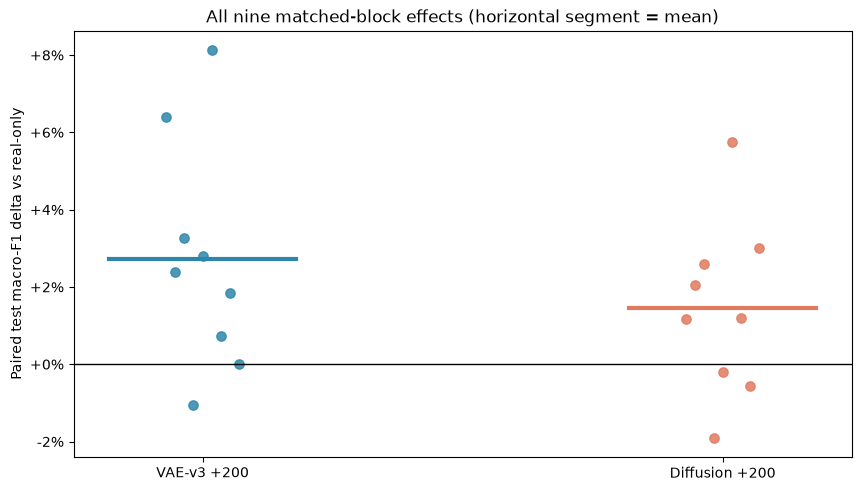

,Generator,Selected generated/species,Real-subset seed,CRNN seed,Pool seed,Accuracy delta,Macro-F1 delta,Robin-recall delta,Cardinal-recall delta,Sparrow-recall delta,Worst-species-recall delta
0,VAE-v3,200,101,42,42.000000,+6.34%,+6.40%,+6.21%,+14.81%,-1.10%,+14.81%
1,VAE-v3,200,101,123,123.000000,+2.04%,+2.39%,+0.69%,+20.99%,-13.74%,+12.87%
2,VAE-v3,200,101,777,777.000000,+3.07%,+3.26%,+7.59%,+8.02%,-4.95%,+8.02%
3,VAE-v3,200,202,42,123.000000,-1.02%,-1.04%,+2.07%,-7.41%,+2.20%,-7.41%
4,VAE-v3,200,202,123,777.000000,+3.07%,+2.81%,+8.28%,-0.62%,+2.20%,-0.62%
5,VAE-v3,200,202,777,42.000000,+7.77%,+8.13%,+1.38%,+19.14%,+2.75%,+19.14%
6,VAE-v3,200,303,42,777.000000,+0.82%,+0.74%,+5.52%,+0.00%,-2.20%,+0.00%
7,VAE-v3,200,303,123,42.000000,+1.84%,+1.84%,+2.07%,+1.85%,+1.65%,+1.85%
8,VAE-v3,200,303,777,123.000000,+0.41%,-0.00%,+4.14%,-10.49%,+7.14%,-10.49%
9,Diffusion,200,101,42,42.000000,+1.43%,+1.17%,-1.38%,+4.32%,+1.10%,+4.32%


In [8]:
plot_data = paired_deltas.copy()
plot_data['Generator'] = plot_data['generator'].map(MODEL_LABELS)
positions = {MODEL_LABELS[model]: index for index, model in enumerate(MODEL_ORDER)}
figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
axis.axhline(0, color='black', linewidth=1)
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    group = plot_data[plot_data['Generator'] == label]
    position = positions[label]
    jitter = np.linspace(-0.07, 0.07, len(group))
    axis.scatter(
        np.full(len(group), position) + jitter, group['delta_macro_f1'],
        s=45, alpha=0.85, color=MODEL_COLORS[model], label=label,
    )
    axis.plot(
        [position - 0.18, position + 0.18],
        [group['delta_macro_f1'].mean()] * 2,
        linewidth=3, color=MODEL_COLORS[model],
    )
axis.set(
    xticks=list(positions.values()),
    xticklabels=[
        f'{MODEL_LABELS[model]} +{selected_ratios[model]}' for model in MODEL_ORDER
    ],
    ylabel='Paired test macro-F1 delta vs real-only',
    title='All nine matched-block effects (horizontal segment = mean)',
)
axis.yaxis.set_major_formatter(lambda value, position: f'{value:+.0%}')
plt.show()

block_delta_columns = [
    'generator', 'selected_ratio_per_species', 'real_subset_seed',
    'train_seed', 'pool_seed', 'delta_accuracy', 'delta_macro_f1',
    'delta_recall_american_robin', 'delta_recall_northern_cardinal',
    'delta_recall_song_sparrow', 'delta_minimum_species_recall',
]
block_view = paired_deltas[block_delta_columns].copy()
block_view['generator'] = block_view['generator'].map(MODEL_LABELS)
block_view = block_view.rename(columns={
    'generator': 'Generator',
    'selected_ratio_per_species': 'Selected generated/species',
    'real_subset_seed': 'Real-subset seed',
    'train_seed': 'CRNN seed', 'pool_seed': 'Pool seed',
    'delta_accuracy': 'Accuracy delta', 'delta_macro_f1': 'Macro-F1 delta',
    'delta_recall_american_robin': 'Robin-recall delta',
    'delta_recall_northern_cardinal': 'Cardinal-recall delta',
    'delta_recall_song_sparrow': 'Sparrow-recall delta',
    'delta_minimum_species_recall': 'Worst-species-recall delta',
})
delta_columns = [column for column in block_view.columns if column.endswith('delta')]
display(block_view.style.format({column: '{:+.2%}' for column in delta_columns}))

## 6. Species recall

Macro F1 gives each species equal weight but can hide which class changes. The table below compares mean CRNN recall and its delta from the matched real-only control.

,Condition,Species,Mean recall,Delta vs real-only
0,Real only,American Robin,90.57%,+0.00%
1,VAE-v3 +200,American Robin,94.79%,+4.21%
2,Diffusion +200,American Robin,88.66%,-1.92%
3,Real only,Northern Cardinal,75.38%,+0.00%
4,VAE-v3 +200,Northern Cardinal,80.52%,+5.14%
5,Diffusion +200,Northern Cardinal,82.51%,+7.13%
6,Real only,Song Sparrow,88.52%,+0.00%
7,VAE-v3 +200,Song Sparrow,87.85%,-0.67%
8,Diffusion +200,Song Sparrow,87.48%,-1.04%


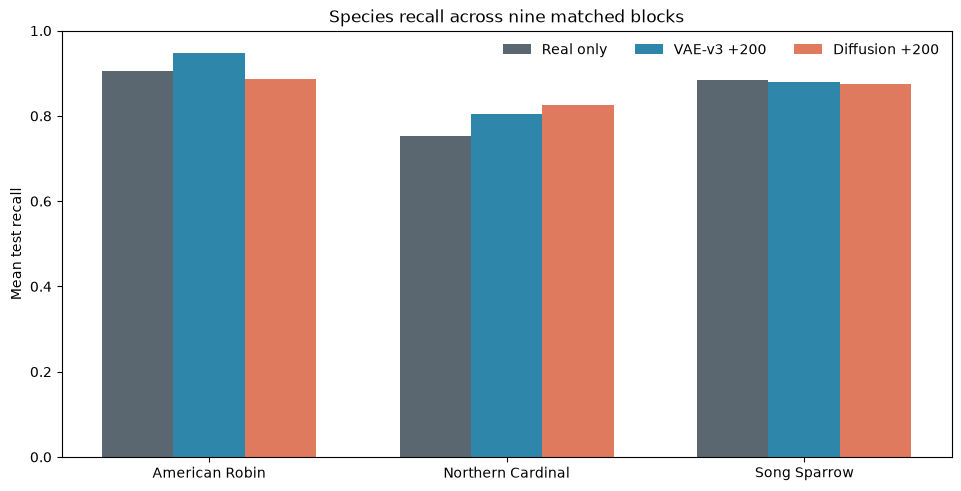

In [9]:
species_columns = {
    'recall_american_robin_mean': 'American Robin',
    'recall_northern_cardinal_mean': 'Northern Cardinal',
    'recall_song_sparrow_mean': 'Song Sparrow',
}
species_view = test_aggregate[['condition', *species_columns]].copy()
species_view['condition'] = species_view['condition'].map(condition_labels)
species_view = species_view.rename(columns={'condition': 'Condition', **species_columns})
baseline_recall = species_view.loc[species_view['Condition'] == 'Real only'].iloc[0]
species_long = species_view.melt(
    id_vars='Condition', var_name='Species', value_name='Mean recall'
)
species_long['Delta vs real-only'] = species_long.apply(
    lambda row: row['Mean recall'] - baseline_recall[row['Species']], axis=1
)
display(species_long.style.format({
    'Mean recall': '{:.2%}', 'Delta vs real-only': '{:+.2%}',
}))

figure, axis = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
species_names = list(species_columns.values())
x = np.arange(len(species_names))
width = 0.24
for index, (_, row) in enumerate(species_view.iterrows()):
    values = [row[name] for name in species_names]
    axis.bar(
        x + (index - 1) * width, values, width,
        label=row['Condition'], color=condition_colors[row['Condition']],
    )
axis.set(
    xticks=x, xticklabels=species_names, ylabel='Mean test recall', ylim=(0, 1),
    title='Species recall across nine matched blocks',
)
axis.legend(frameon=False, ncols=3)
plt.show()

## 7. Code-derived result and caveats

The next cell derives the final held-out summary and interval interpretation directly from the hardened report rows, then presents the experiment's limitations.

In [10]:
aggregate_index = test_aggregate.set_index('condition')
paired_index = paired_summary.set_index('generator')
baseline_macro_f1 = float(aggregate_index.loc['real_only', 'macro_f1_mean'])
result_records = []
for model in MODEL_ORDER:
    paired_row = paired_index.loc[model]
    interval_low = float(paired_row['delta_macro_f1_bootstrap_95_low'])
    interval_high = float(paired_row['delta_macro_f1_bootstrap_95_high'])
    if interval_low > 0:
        interval_position = 'entirely above zero'
    elif interval_high < 0:
        interval_position = 'entirely below zero'
    else:
        interval_position = 'spans zero'
    result_records.append({
        'Generator': MODEL_LABELS[model],
        'Selected generated/species': selected_ratios[model],
        'Real-only macro F1': baseline_macro_f1,
        'Synthetic-arm macro F1': float(
            aggregate_index.loc[condition_codes[model], 'macro_f1_mean']
        ),
        'Mean paired delta': float(paired_row['delta_macro_f1_mean']),
        'Interval low': interval_low,
        'Interval high': interval_high,
        'Positive blocks': int(paired_row['delta_macro_f1_positive_blocks']),
        'Interval position': interval_position,
    })
results = pd.DataFrame(result_records)
display(results.style.format({
    'Real-only macro F1': '{:.2%}', 'Synthetic-arm macro F1': '{:.2%}',
    'Mean paired delta': '{:+.2%}', 'Interval low': '{:+.2%}',
    'Interval high': '{:+.2%}',
}))
for _, row in results.iterrows():
    print(
        f"{row['Generator']} +{int(row['Selected generated/species'])}/species: "
        f"mean paired macro-F1 delta {row['Mean paired delta']:+.2%}, "
        f"descriptive interval {row['Interval low']:+.2%} to "
        f"{row['Interval high']:+.2%} ({row['Interval position']}), "
        f"positive in {int(row['Positive blocks'])}/{len(expected_blocks)} blocks."
    )

reported_caveats = [
    str(value)
    for value in summary['caveats']
    if not str(value).lower().startswith('the selected ')
]
selection_caveat = (
    f"Validation searched only {protocol['ratios_per_species']}; selected ratios are "
    'best-tested choices under the stated tie rule, not estimated global optima.'
)
caveats = [*reported_caveats, selection_caveat]
display(pd.DataFrame({'Caveat': caveats}))

,Generator,Selected generated/species,Real-only macro F1,Synthetic-arm macro F1,Mean paired delta,Interval low,Interval high,Positive blocks,Interval position
0,VAE-v3,200,84.75%,87.48%,+2.72%,+1.00%,+4.65%,7,entirely above zero
1,Diffusion,200,84.75%,86.21%,+1.46%,+0.15%,+2.89%,6,entirely above zero


VAE-v3 +200/species: mean paired macro-F1 delta +2.72%, descriptive interval +1.00% to +4.65% (entirely above zero), positive in 7/9 blocks.
Diffusion +200/species: mean paired macro-F1 delta +1.46%, descriptive interval +0.15% to +2.89% (entirely above zero), positive in 6/9 blocks.


,Caveat
0,The three evaluated birds are a simulated low-...
1,The classifiers receive only 50 labeled real r...
2,The current 489-clip project test set has prio...
3,Real-subset seeds are repeated subsamples of t...
4,9 paired blocks support a descriptive stabilit...
5,"Validation selected vae_v3=+200/species, diffu..."
6,"Validation searched only [50, 100, 200]; selec..."


## Reproduction boundary

The current protocol is implemented by `scripts/15_crnn_low_resource_augmentation.py`. From the repository root:

```powershell
$env:PYTHONPATH = (Resolve-Path 'src').Path
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py audit
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py run --device cuda --workers 0
```

The command trains only the CRNN conditions and packages bounded evidence under the report path. Re-executing this report-only notebook reads those artifacts; it does not train a classifier or generate any VAE or diffusion spectrograms.